In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv('../data/sales_data.csv', sep=';')
df.head()

,Ano,Mês,BaciaAgregada,Preço em Reais por MMBtu,Volume em mil metros cúbicos/dia
0,2019,9,Demais Bacias,"24,4",2906
1,2019,9,Campos,"7,4",1185
2,2019,9,Santos,"8,8",11213
3,2019,10,Demais Bacias,"24,4",2887
4,2019,10,Campos,9,1078


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Ano                               216 non-null    int64 
 1   Mês                               216 non-null    int64 
 2   BaciaAgregada                     216 non-null    object
 3   Preço em Reais por MMBtu          203 non-null    object
 4   Volume em mil metros cúbicos/dia  216 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 8.6+ KB


In [28]:
df.describe()

,Ano,Mês,Volume em mil metros cúbicos/dia
count,216.000000,216.000000,216.000000
mean,2022.166667,6.500000,4415.722222
std,1.775806,3.460071,4307.936970
min,2019.000000,1.000000,161.000000
25%,2021.000000,3.750000,992.750000
50%,2022.000000,6.500000,2018.500000
75%,2024.000000,9.250000,9958.750000
max,2025.000000,12.000000,13546.000000


In [29]:
print(df.columns)

Index(['Ano', 'Mês', 'BaciaAgregada', 'Preço em Reais por MMBtu',
       'Volume em mil metros cúbicos/dia'],
      dtype='object')


In [30]:
df.columns = [
    'Ano',
    'Mes',
    'Bacia',
    'Preco',
    'Volume'
]

In [31]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Ano     216 non-null    int64 
 1   Mes     216 non-null    int64 
 2   Bacia   216 non-null    object
 3   Preco   203 non-null    object
 4   Volume  216 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 8.6+ KB


In [33]:
df['Preco'] = pd.to_numeric(df['Preco'], errors='coerce')
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

In [34]:
df = df.dropna()
df = df.drop_duplicates()

In [35]:
df['Preco'].mean()

np.float64(24.375)

In [36]:
df['Volume'].sum()

np.int64(73104)

In [37]:
volume_por_bacia = df.groupby('Bacia')['Volume'].sum().sort_values(ascending=False)
volume_por_bacia

Bacia
Santos           54372
Demais Bacias    12453
Campos            6279
Name: Volume, dtype: int64

In [38]:
preco_por_bacia = df.groupby('Bacia')['Preco'].mean().sort_values(ascending=False)
preco_por_bacia

Bacia
Demais Bacias    31.000000
Campos           22.166667
Santos           20.400000
Name: Preco, dtype: float64

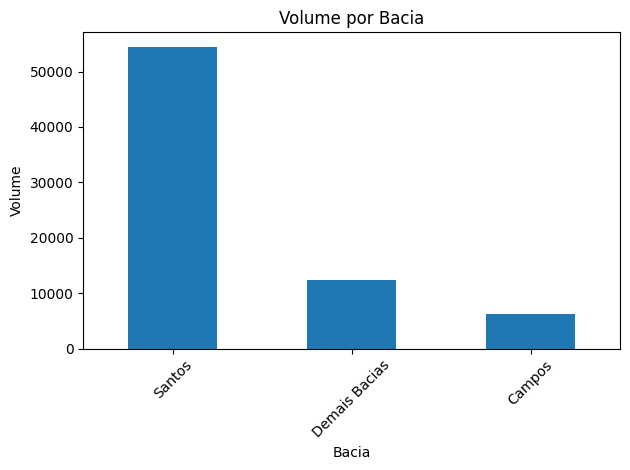

In [39]:
volume_por_bacia.plot(kind='bar')
plt.title('Volume por Bacia')
plt.xlabel('Bacia')
plt.ylabel('Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

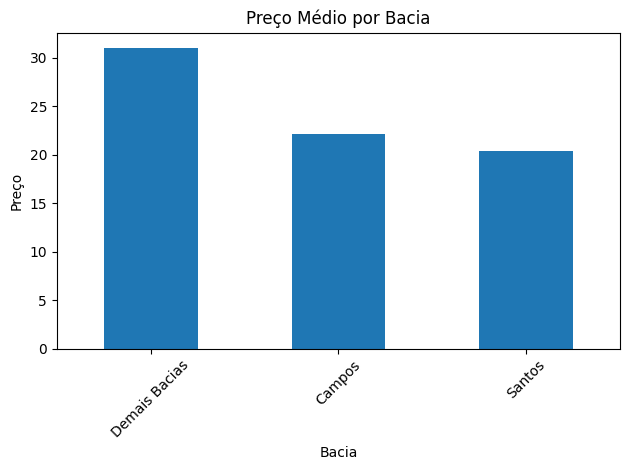

In [40]:
preco_por_bacia.plot(kind='bar')
plt.title('Preço Médio por Bacia')
plt.xlabel('Bacia')
plt.ylabel('Preço')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
df['Data'] = df['Ano'].astype(str) + '-' + df['Mes'].astype(str)
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')

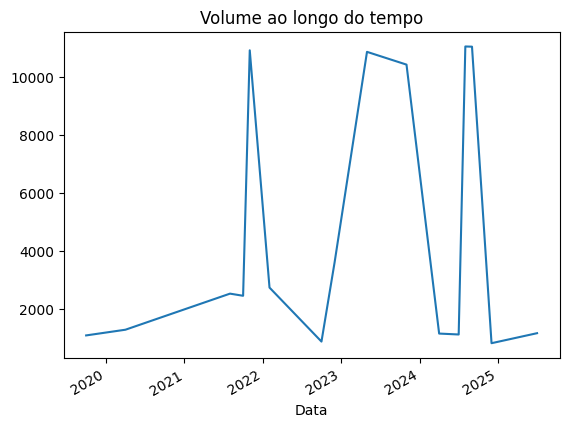

In [42]:
volume_tempo = df.groupby('Data')['Volume'].sum()
volume_tempo.plot()
plt.title('Volume ao longo do tempo')
plt.show()

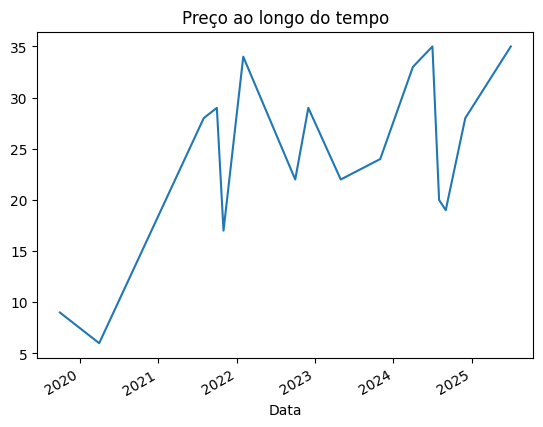

In [43]:
preco_tempo = df.groupby('Data')['Preco'].mean()
preco_tempo.plot()
plt.title('Preço ao longo do tempo')
plt.show()

## Insights

- A bacia com maior volume foi Santos
- O preço médio variou ao longo do tempo mostrando quedas bruscas nas passagens entre anos
- Existe relação entre volume e preço em alguns períodos
- O comportamento do mercado indica baixa no mercado durante fim de ano e fortalecimento na metade, 2026 vem na maior crescente histórica

In [44]:
df.head()

,Ano,Mes,Bacia,Preco,Volume,Data
4,2019,10,Campos,9.0,1078,2019-10-01
22,2020,4,Campos,6.0,1275,2020-04-01
69,2021,8,Demais Bacias,28.0,2522,2021-08-01
75,2021,10,Demais Bacias,29.0,2448,2021-10-01
79,2021,11,Santos,17.0,10932,2021-11-01


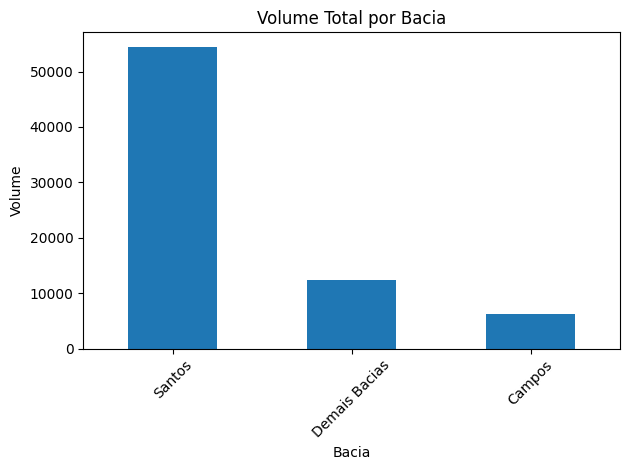

In [46]:
volume_por_bacia.plot(kind='bar')
plt.title('Volume Total por Bacia')
plt.xlabel('Bacia')
plt.ylabel('Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
df[['Preco', 'Volume']].corr()

,Preco,Volume
Preco,1.00000,-0.27327
Volume,-0.27327,1.00000


## Insights

- A análise indica que existe uma correlação negativa fraca (-0.27) entre preço e volume, sugerindo que, em geral, aumentos no preço podem estar associados a leves reduções no volume, embora essa relação não seja forte.
- O volume de produção varia significativamente entre as bacias, indicando diferenças relevantes na capacidade produtiva de cada região.
- O preço médio apresenta variações entre as bacias, o que pode estar relacionado a fatores como logística, oferta e características específicas de cada região.
- Ao longo do tempo, os dados apresentam oscilações tanto no preço quanto no volume, indicando possíveis influências de fatores de mercado e demanda.
- A relação entre preço e volume não é determinante, sugerindo que outros fatores além do preço impactam o volume de produção.